# Balanced Federated Benchmark: Cross-Seed Analysis

**Analysis objective.** Determine when FedAvg, FedProx, and
SCAFFOLD differ under controlled label, quantity, and rotation
heterogeneity.

This notebook is analysis-only: it reads the immutable archive
produced by Notebook 9 and never trains a model.

## Prespecified questions

1. Which algorithms retain global and client-local accuracy as
   heterogeneity changes?
2. Which differences persist across seeds rather than appearing in
   one partition?
3. Does an algorithm improve the worst-served client?
4. What runtime cost accompanies any accuracy improvement?

Results are reported as mean ± sample standard deviation across
three seeds. With only three seeds, uncertainty estimates are
descriptive; small differences should not be presented as
statistically decisive.


## 1. Imports and visual style


In [17]:
from __future__ import annotations

import os
import tempfile
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "legend.frameon": False,
})

ALGORITHM_ORDER = ["fedavg", "fedprox", "scaffold"]
ALGORITHM_LABELS = {
    "fedavg": "FedAvg",
    "fedprox": "FedProx (μ=0.01)",
    "scaffold": "SCAFFOLD",
}
COLORS = {
    "fedavg": "#4C78A8",
    "fedprox": "#F58518",
    "scaffold": "#54A24B",
}
LINESTYLES = {
    "fedavg": "--",
    "fedprox": ":",
    "scaffold": "-",
}
CONDITION_ORDER = [
    "IID",
    "Label α=0.5",
    "Label α=0.1",
    "Quantity α=0.5",
    "Quantity α=0.1",
    "Rotation ±10°",
    "Rotation ±20°",
]


## 2. Locate and unpack the result archive

Set `BENCHMARK_ARCHIVE` when the ZIP is outside the usual project,
Kaggle working, or notebook directories. Extraction is idempotent.


In [18]:
ARCHIVE_NAME = "balanced_benchmark_v1_complete.zip"

explicit_archive = os.environ.get("BENCHMARK_ARCHIVE")
candidates = [
    Path(explicit_archive) if explicit_archive else None,
    Path.cwd() / ARCHIVE_NAME,
    Path.cwd().parent / ARCHIVE_NAME,
    Path.cwd() / "results" / ARCHIVE_NAME,
    Path.cwd().parent / "results" / ARCHIVE_NAME,
    Path("/kaggle/working") / ARCHIVE_NAME,
]

archive_path = next(
    (path.resolve() for path in candidates if path and path.exists()),
    None,
)

if archive_path is None:
    kaggle_matches = list(
        Path("/kaggle/input").glob(f"**/{ARCHIVE_NAME}")
    ) if Path("/kaggle/input").exists() else []
    archive_path = kaggle_matches[0] if kaggle_matches else None

if archive_path is None:
    raise FileNotFoundError(
        f"Could not locate {ARCHIVE_NAME}. Set BENCHMARK_ARCHIVE "
        "to its absolute path."
    )

analysis_root = Path(
    os.environ.get(
        "BENCHMARK_ANALYSIS_ROOT",
        Path.cwd() / "balanced_benchmark_analysis",
    )
)
extracted_root = analysis_root / "archive"
figure_directory = analysis_root / "figures"
table_directory = analysis_root / "tables"

extracted_root.mkdir(parents=True, exist_ok=True)
figure_directory.mkdir(parents=True, exist_ok=True)
table_directory.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(archive_path) as archive:
    corrupt_member = archive.testzip()
    if corrupt_member is not None:
        raise RuntimeError(f"Corrupt ZIP member: {corrupt_member}")
    archive.extractall(extracted_root)

combined_directory = extracted_root / "combined"
print("Archive:", archive_path)
print("Analysis outputs:", analysis_root.resolve())


Archive: /kaggle/working/balanced_benchmark_v1_complete.zip
Analysis outputs: /kaggle/working/balanced_benchmark_analysis


## 3. Load the analysis tables


In [19]:
summary = pd.read_csv(combined_directory / "summary.csv")
validation_by_round = pd.read_csv(
    combined_directory / "validation_by_round.csv"
)
validation_by_client = pd.read_csv(
    combined_directory / "validation_by_client.csv"
)
local_test_by_client = pd.read_csv(
    combined_directory / "local_test_by_client.csv"
)
client_updates = pd.read_csv(
    combined_directory / "client_update_diagnostics.csv"
)
pairwise_updates = pd.read_csv(
    combined_directory / "pairwise_update_diagnostics.csv"
)
round_diagnostics = pd.read_csv(
    combined_directory / "round_diagnostics.csv"
)
condition_preflight = pd.read_csv(
    combined_directory / "condition_preflight.csv"
)


def condition_label(frame: pd.DataFrame) -> pd.Series:
    labels = pd.Series(index=frame.index, dtype="object")
    labels.loc[frame["mode"].eq("iid")] = "IID"

    label_mask = frame["mode"].eq("label_skew")
    labels.loc[label_mask] = frame.loc[label_mask, "alpha"].map(
        lambda value: f"Label α={value:g}"
    )

    quantity_mask = frame["mode"].eq("quantity_skew")
    labels.loc[quantity_mask] = frame.loc[quantity_mask, "alpha"].map(
        lambda value: f"Quantity α={value:g}"
    )

    rotation_mask = frame["mode"].eq("rotation_shift")
    labels.loc[rotation_mask] = frame.loc[
        rotation_mask,
        "max_abs_angle",
    ].map(lambda value: f"Rotation ±{value:g}°")
    return labels


for frame in (
    summary,
    validation_by_round,
    validation_by_client,
    local_test_by_client,
    client_updates,
    pairwise_updates,
    round_diagnostics,
    condition_preflight,
):
    frame["condition"] = condition_label(frame)
    frame["condition"] = pd.Categorical(
        frame["condition"],
        categories=CONDITION_ORDER,
        ordered=True,
    )

print("Summary rows:", len(summary))
print("Validation rows:", len(validation_by_round))


Summary rows: 63
Validation rows: 1323


## 4. Integrity and fairness audit

These checks establish that the archive represents the intended
protocol before inspecting outcomes. In particular, identical
round-zero validation values show that algorithms within each
condition began from the same model and evaluation data.


In [20]:
assert len(summary) == 63
assert summary.groupby(
    ["condition", "seed", "algorithm"],
    observed=True,
).size().eq(1).all()
assert summary.groupby("algorithm").size().eq(21).all()
assert set(summary["seed"]) == {42, 43, 44}

rows_per_run = validation_by_round.groupby("run_key").size()
assert rows_per_run.eq(21).all()
assert all(
    set(run_frame["round"]) == set(range(21))
    for _, run_frame in validation_by_round.groupby("run_key")
)
assert local_test_by_client.groupby("run_key").size().eq(5).all()
assert len(condition_preflight) == 21

round_zero = validation_by_round.query("round == 0")
round_zero_span = round_zero.groupby(
    ["condition", "seed"],
    observed=True,
)["weighted_accuracy"].agg(lambda values: values.max() - values.min())
assert np.allclose(round_zero_span.to_numpy(), 0.0)

accuracy_columns = [
    "weighted_accuracy",
    "mean_client_accuracy",
    "worst_client_accuracy",
    "std_client_accuracy",
    "p10_client_accuracy",
]
assert np.isfinite(
    validation_by_round[accuracy_columns].to_numpy()
).all()

audit = pd.Series({
    "completed runs": len(summary),
    "conditions": summary["condition"].nunique(),
    "seeds": summary["seed"].nunique(),
    "algorithms": summary["algorithm"].nunique(),
    "validation rounds per run": rows_per_run.iloc[0],
    "clients per run": 5,
    "maximum round-zero algorithm difference": round_zero_span.max(),
}, name="value")
display(audit.to_frame())


,value
completed runs,63.0
conditions,7.0
seeds,3.0
algorithms,3.0
validation rounds per run,21.0
clients per run,5.0
maximum round-zero algorithm difference,NaN


## 5. Realized heterogeneity

Requested parameters such as α are not themselves outcome
measures. The realized metadata verifies what changed:

- `mean_label_tvd`: average client distance from the global label distribution;
- `quantity_cv`: relative dispersion of client sample counts;
- `rotation_std_degrees`: spread of fixed client rotations.

The severity axes are family-specific and should not be compared as
if they shared a common numerical scale.


In [21]:
realized_heterogeneity = (
    condition_preflight
    .groupby("condition", observed=True)
    .agg(
        min_client_size=("min_client_size", "mean"),
        max_client_size=("max_client_size", "mean"),
        quantity_cv=("quantity_cv", "mean"),
        mean_label_tvd=("mean_label_tvd", "mean"),
        rotation_std_degrees=("rotation_std_degrees", "mean"),
    )
    .reindex(CONDITION_ORDER)
    .round(4)
)
display(realized_heterogeneity)
realized_heterogeneity.to_csv(
    table_directory / "realized_heterogeneity.csv"
)


,min_client_size,max_client_size,quantity_cv,mean_label_tvd,rotation_std_degrees
condition,,,,,
IID,12000.0,12000.0000,0.0000,0.0100,0.0000
Label α=0.5,12000.0,12000.0000,0.0000,0.3731,0.0000
Label α=0.1,12000.0,12000.0000,0.0000,0.5140,0.0000
Quantity α=0.5,571.0,33928.0000,1.0297,0.0289,0.0000
Quantity α=0.1,100.0,46496.6667,1.4810,0.0541,0.0000
Rotation ±10°,12000.0,12000.0000,0.0000,0.0100,7.0711
Rotation ±20°,12000.0,12000.0000,0.0000,0.0100,14.1421


## 6. Final global-test performance

The clean global test set measures generalization to the original
MNIST distribution. Bars show the mean across seeds; error bars show
one sample standard deviation. Error bars are descriptive because
each estimate contains only three seeds.


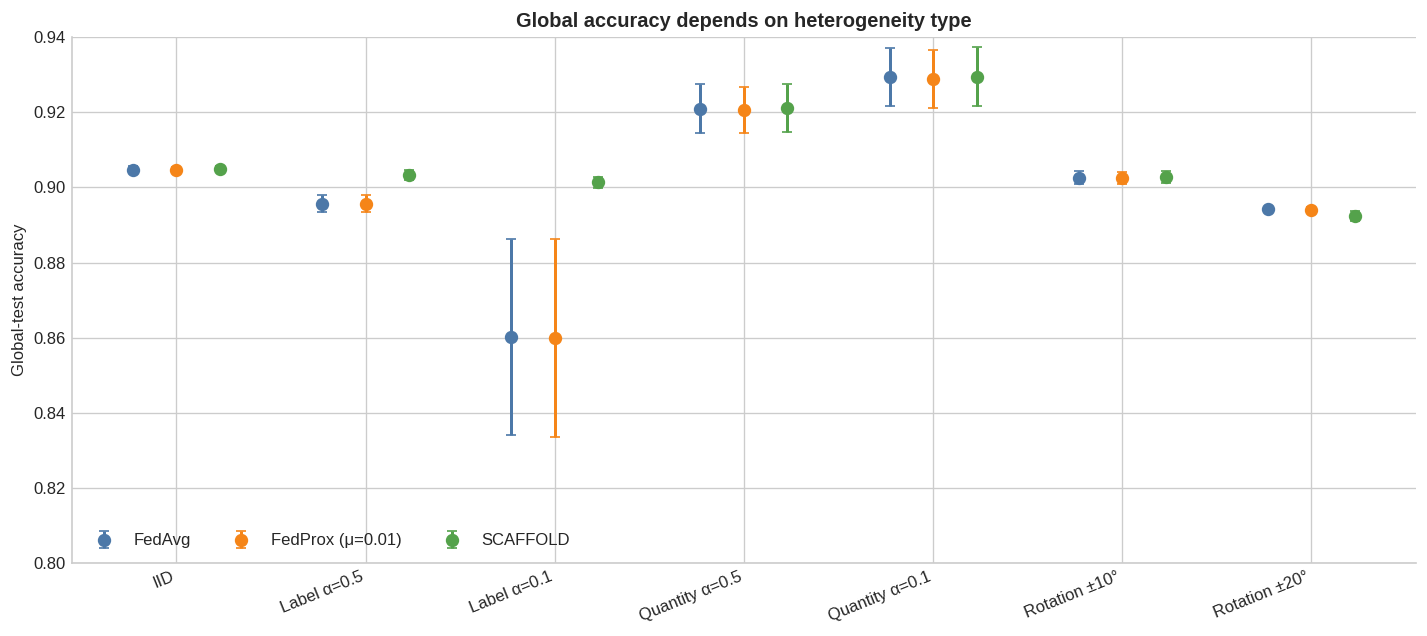

algorithm,FedAvg,FedProx (μ=0.01),SCAFFOLD
condition,,,
IID,0.9047 ± 0.0009,0.9046 ± 0.0008,0.9048 ± 0.0008
Label α=0.5,0.8957 ± 0.0022,0.8957 ± 0.0022,0.9034 ± 0.0013
Label α=0.1,0.8603 ± 0.0261,0.8599 ± 0.0264,0.9014 ± 0.0015
Quantity α=0.5,0.9209 ± 0.0065,0.9207 ± 0.0061,0.9212 ± 0.0064
Quantity α=0.1,0.9294 ± 0.0078,0.9289 ± 0.0077,0.9295 ± 0.0078
Rotation ±10°,0.9026 ± 0.0017,0.9025 ± 0.0017,0.9027 ± 0.0016
Rotation ±20°,0.8942 ± 0.0006,0.8939 ± 0.0008,0.8925 ± 0.0013


In [22]:
def aggregate_metric(metric: str) -> pd.DataFrame:
    return (
        summary
        .groupby(["condition", "algorithm"], observed=True)[metric]
        .agg(mean="mean", std="std", count="size")
        .reset_index()
    )


def grouped_mean_sd_plot(
    metric: str,
    ylabel: str,
    title: str,
    filename: str,
    ylim: tuple[float, float] | None = None,
) -> pd.DataFrame:
    aggregate = aggregate_metric(metric)
    x = np.arange(len(CONDITION_ORDER), dtype=float)
    width = 0.23

    fig, ax = plt.subplots(figsize=(12, 5.4))
    for index, algorithm in enumerate(ALGORITHM_ORDER):
        subset = (
            aggregate[aggregate["algorithm"].eq(algorithm)]
            .set_index("condition")
            .reindex(CONDITION_ORDER)
        )
        positions = x + (index - 1) * width
        ax.errorbar(
            positions,
            subset["mean"],
            yerr=subset["std"],
            fmt="o",
            markersize=7,
            linewidth=1.8,
            capsize=3,
            color=COLORS[algorithm],
            label=ALGORITHM_LABELS[algorithm],
        )

    ax.set_xticks(x, CONDITION_ORDER, rotation=22, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend(ncol=3, loc="lower left")
    fig.tight_layout()
    fig.savefig(figure_directory / filename, bbox_inches="tight")
    plt.show()
    return aggregate


global_aggregate = grouped_mean_sd_plot(
    metric="global_test_accuracy",
    ylabel="Global-test accuracy",
    title="Global accuracy depends on heterogeneity type",
    filename="global_accuracy_by_condition.png",
    ylim=(0.80, 0.94),
)

global_table = (
    global_aggregate
    .assign(
        value=lambda frame: frame.apply(
            lambda row: f"{row['mean']:.4f} ± {row['std']:.4f}",
            axis=1,
        )
    )
    .pivot(index="condition", columns="algorithm", values="value")
    .reindex(index=CONDITION_ORDER, columns=ALGORITHM_ORDER)
    .rename(columns=ALGORITHM_LABELS)
)
display(global_table)
global_table.to_csv(table_directory / "global_accuracy_mean_sd.csv")


### Paired algorithm differences

Comparisons are paired by condition and seed. This controls for
partition difficulty better than comparing unpaired overall means.
`wins` counts strictly positive differences; it is descriptive, not
a formal hypothesis test.


In [23]:
paired_global = summary.pivot(
    index=["condition", "seed"],
    columns="algorithm",
    values="global_test_accuracy",
)

comparisons = {
    "FedProx − FedAvg": paired_global["fedprox"] - paired_global["fedavg"],
    "SCAFFOLD − FedAvg": paired_global["scaffold"] - paired_global["fedavg"],
    "SCAFFOLD − FedProx": paired_global["scaffold"] - paired_global["fedprox"],
}

paired_summary = pd.DataFrame({
    name: {
        "mean difference": values.mean(),
        "median difference": values.median(),
        "wins": int(values.gt(0).sum()),
        "ties": int(values.eq(0).sum()),
        "losses": int(values.lt(0).sum()),
    }
    for name, values in comparisons.items()
}).T

display(paired_summary.round(5))
paired_summary.to_csv(table_directory / "paired_global_differences.csv")


,mean difference,median difference,wins,ties,losses
FedProx − FedAvg,-0.00022,-0.0002,1.0,7.0,13.0
SCAFFOLD − FedAvg,0.00683,0.0002,14.0,2.0,5.0
SCAFFOLD − FedProx,0.00705,0.0005,16.0,1.0,4.0


## 7. Robustness under strong label skew

Label skew α=0.1 is the condition where seed-to-seed partition
variation most strongly affects FedAvg and FedProx. Showing each
seed prevents an average from hiding this instability.


algorithm,FedAvg,FedProx (μ=0.01),SCAFFOLD
seed,,,
42,0.8901,0.8901,0.9031
43,0.8488,0.8483,0.9006
44,0.8419,0.8414,0.9004


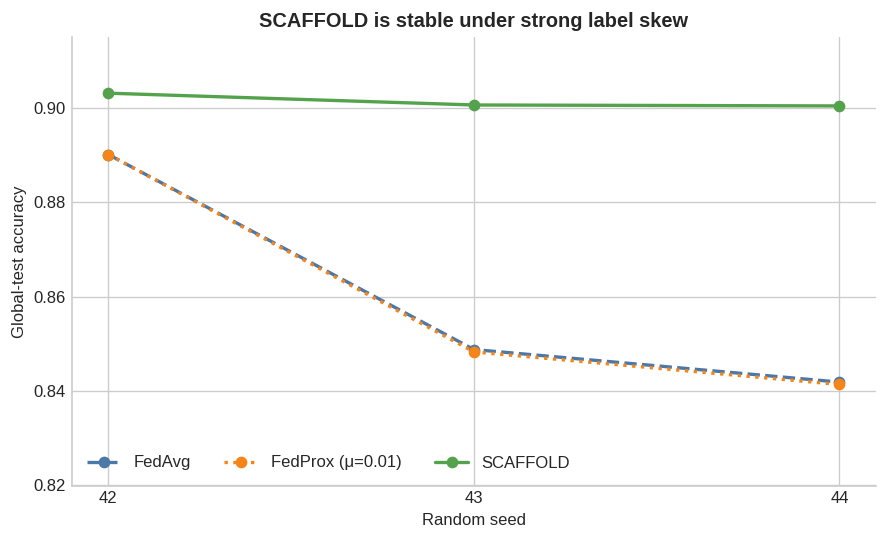

In [24]:
strong_label = summary[
    summary["condition"].eq("Label α=0.1")
].copy()

strong_label_table = strong_label.pivot(
    index="seed",
    columns="algorithm",
    values="global_test_accuracy",
).reindex(columns=ALGORITHM_ORDER).rename(columns=ALGORITHM_LABELS)
display(strong_label_table.round(4))

fig, ax = plt.subplots(figsize=(7.5, 4.6))
for algorithm in ALGORITHM_ORDER:
    subset = strong_label[
        strong_label["algorithm"].eq(algorithm)
    ].sort_values("seed")
    ax.plot(
        subset["seed"].astype(str),
        subset["global_test_accuracy"],
        marker="o",
        linewidth=2,
        markersize=6,
        color=COLORS[algorithm],
        linestyle=LINESTYLES[algorithm],
        label=ALGORITHM_LABELS[algorithm],
    )
ax.set_xlabel("Random seed")
ax.set_ylabel("Global-test accuracy")
ax.set_title("SCAFFOLD is stable under strong label skew")
ax.set_ylim(0.82, 0.915)
ax.legend(ncol=3, loc="lower left")
fig.tight_layout()
fig.savefig(
    figure_directory / "strong_label_skew_seed_robustness.png",
    bbox_inches="tight",
)
plt.show()


## 8. Convergence under strong label skew

Curves show the mean validation accuracy across seeds. Shading is ±1
sample standard deviation. Round zero is shared exactly across
algorithms; subsequent separation therefore reflects training, not
different starting models.


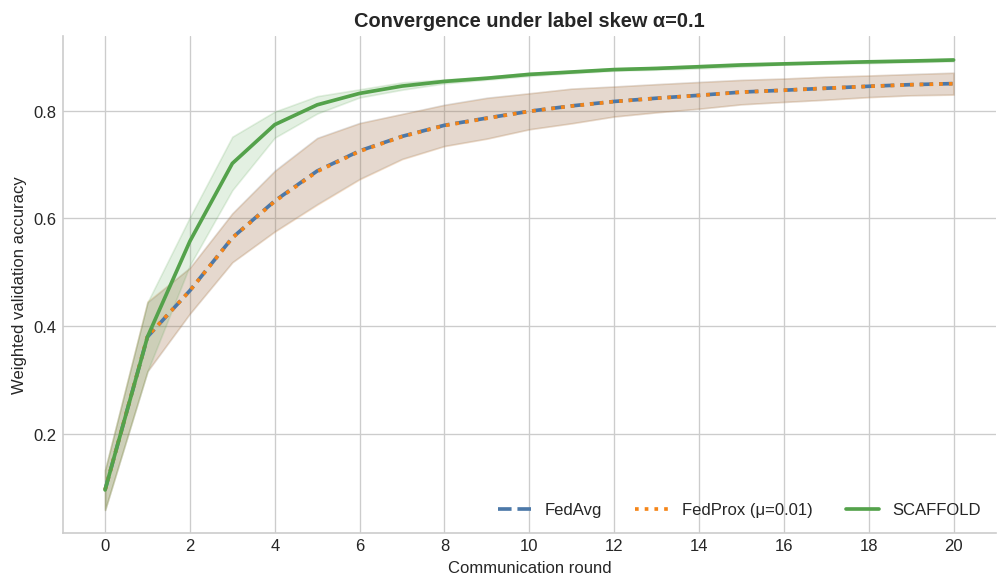

In [25]:
strong_label_history = validation_by_round[
    validation_by_round["condition"].eq("Label α=0.1")
]
curve = (
    strong_label_history
    .groupby(["algorithm", "round"])["weighted_accuracy"]
    .agg(mean="mean", std="std")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8.5, 5))
for algorithm in ALGORITHM_ORDER:
    subset = curve[curve["algorithm"].eq(algorithm)]
    x = subset["round"].to_numpy()
    mean = subset["mean"].to_numpy()
    std = subset["std"].to_numpy()
    ax.plot(
        x,
        mean,
        linewidth=2.2,
        color=COLORS[algorithm],
        linestyle=LINESTYLES[algorithm],
        label=ALGORITHM_LABELS[algorithm],
    )
    ax.fill_between(
        x,
        mean - std,
        mean + std,
        color=COLORS[algorithm],
        alpha=0.16,
    )

ax.set_xlabel("Communication round")
ax.set_ylabel("Weighted validation accuracy")
ax.set_title("Convergence under label skew α=0.1")
ax.set_xticks(range(0, 21, 2))
ax.legend(ncol=3, loc="lower right")
fig.tight_layout()
fig.savefig(
    figure_directory / "label_skew_0p1_convergence.png",
    bbox_inches="tight",
)
plt.show()

tail_scores = (
    validation_by_round[validation_by_round["round"].between(16, 20)]
    .groupby(["condition", "seed", "algorithm"], observed=True)
    ["weighted_accuracy"]
    .mean()
    .rename("tail_validation_accuracy")
    .reset_index()
)
tail_summary = (
    tail_scores
    .groupby(["condition", "algorithm"], observed=True)
    ["tail_validation_accuracy"]
    .agg(["mean", "std"])
)
tail_summary.to_csv(table_directory / "tail_validation_summary.csv")


## 9. Client-level service and fairness

Global accuracy alone can hide clients that are poorly served.
`local_test_weighted_accuracy` evaluates the final global model on
held-out data from the heterogeneous client environments, while
`local_test_worst_client_accuracy` isolates the least accurate
client in each run.


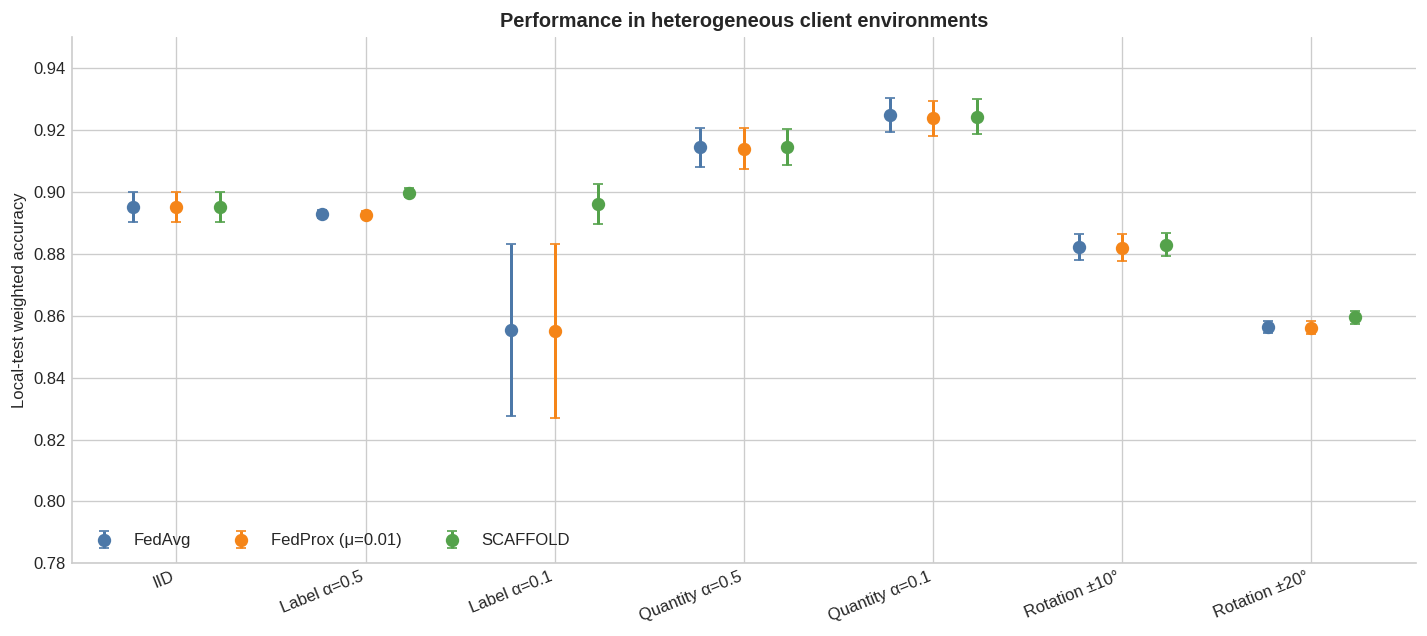

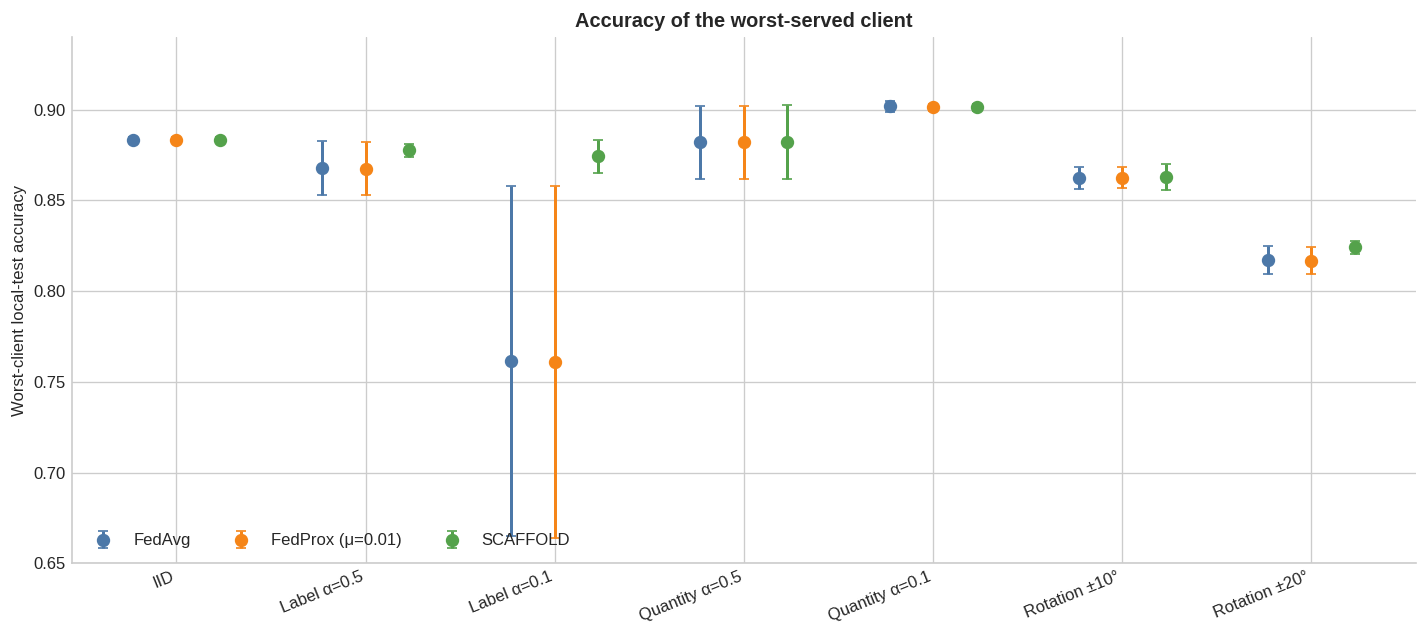

In [26]:
local_aggregate = grouped_mean_sd_plot(
    metric="local_test_weighted_accuracy",
    ylabel="Local-test weighted accuracy",
    title="Performance in heterogeneous client environments",
    filename="local_weighted_accuracy_by_condition.png",
    ylim=(0.78, 0.95),
)

worst_aggregate = grouped_mean_sd_plot(
    metric="local_test_worst_client_accuracy",
    ylabel="Worst-client local-test accuracy",
    title="Accuracy of the worst-served client",
    filename="worst_client_accuracy_by_condition.png",
    ylim=(0.65, 0.94),
)


### Clean-global versus rotated-client trade-off

Rotation ±20° produces different evaluation domains. The clean
global test set asks whether the model transfers back to unrotated
MNIST; the local test asks how well it serves the actual rotated
clients. These results should not be collapsed into one number.


In [27]:
rotation_20 = summary[
    summary["condition"].eq("Rotation ±20°")
]
rotation_tradeoff = (
    rotation_20
    .groupby("algorithm")
    .agg(
        clean_global=("global_test_accuracy", "mean"),
        local_weighted=("local_test_weighted_accuracy", "mean"),
        worst_client=("local_test_worst_client_accuracy", "mean"),
    )
    .reindex(ALGORITHM_ORDER)
    .rename(index=ALGORITHM_LABELS)
)
display(rotation_tradeoff.round(4))
rotation_tradeoff.to_csv(table_directory / "rotation_20_tradeoff.csv")


,clean_global,local_weighted,worst_client
algorithm,,,
FedAvg,0.8942,0.8564,0.8172
FedProx (μ=0.01),0.8939,0.8561,0.8167
SCAFFOLD,0.8925,0.8594,0.8242


## 10. Runtime

Runtime is measured uniformly around each complete algorithm run,
with CUDA synchronization before and after timing. It includes
training-time validation but excludes the adapters' final local and
global test evaluation. Rotation transforms are applied during data
loading and therefore legitimately contribute to runtime.


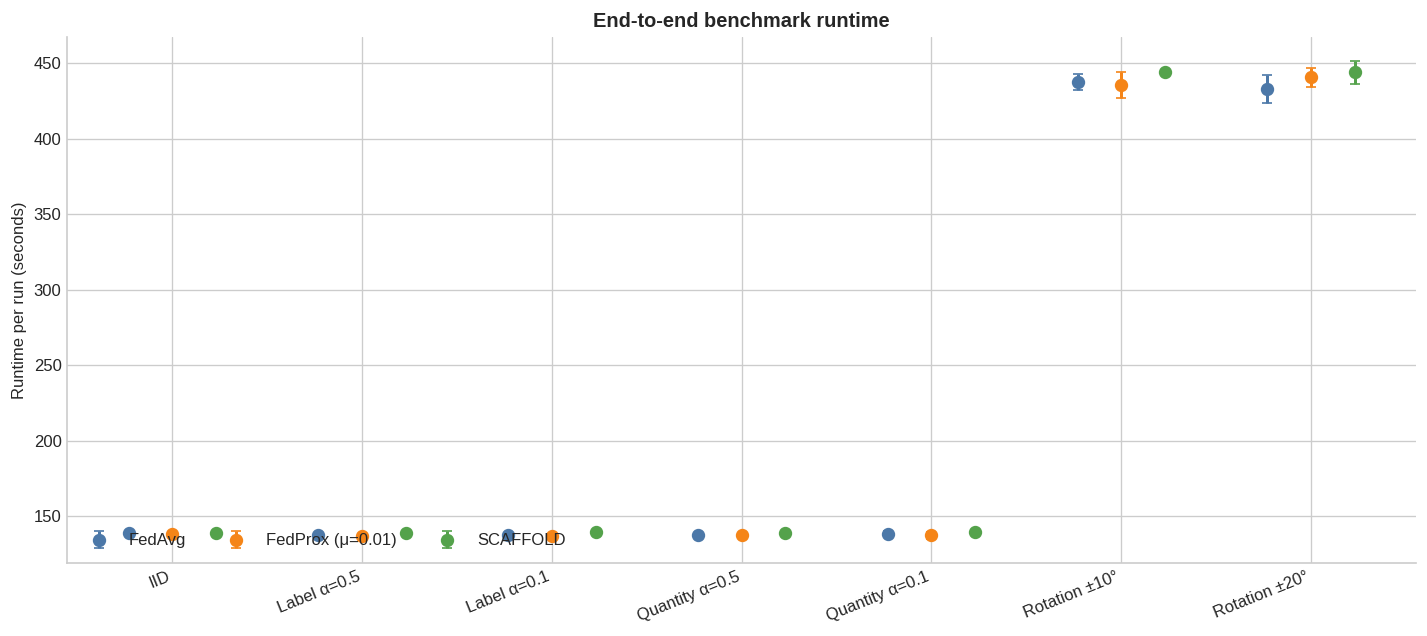

,mean_seconds,std_seconds,total_seconds
algorithm,,,
FedAvg,222.93,137.65,4681.54
FedProx (μ=0.01),223.46,139.16,4692.71
SCAFFOLD,226.42,141.17,4754.89


In [28]:
runtime_aggregate = grouped_mean_sd_plot(
    metric="runtime_seconds",
    ylabel="Runtime per run (seconds)",
    title="End-to-end benchmark runtime",
    filename="runtime_by_condition.png",
    ylim=None,
)

runtime_summary = (
    summary
    .groupby("algorithm")["runtime_seconds"]
    .agg(mean_seconds="mean", std_seconds="std", total_seconds="sum")
    .reindex(ALGORITHM_ORDER)
    .rename(index=ALGORITHM_LABELS)
)
display(runtime_summary.round(2))
runtime_summary.to_csv(table_directory / "runtime_summary.csv")


## 11. Update-geometry diagnostic

Pairwise cosine similarity measures whether client updates point in
similar directions. It is mechanistic evidence, not a performance
endpoint. We summarize it by round for the severe label-skew case,
where the outcome differences are largest.


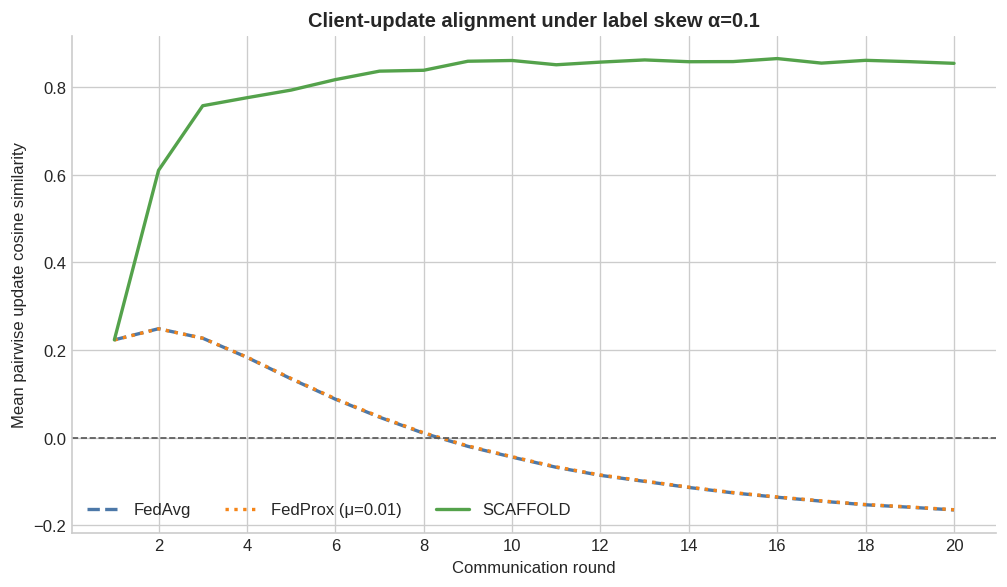

In [29]:
pairwise_label = pairwise_updates[
    pairwise_updates["condition"].eq("Label α=0.1")
]
pairwise_curve = (
    pairwise_label
    .groupby(["algorithm", "round"])["cosine_similarity"]
    .agg(mean="mean", std="std")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8.5, 5))
for algorithm in ALGORITHM_ORDER:
    subset = pairwise_curve[pairwise_curve["algorithm"].eq(algorithm)]
    ax.plot(
        subset["round"],
        subset["mean"],
        linewidth=2,
        color=COLORS[algorithm],
        linestyle=LINESTYLES[algorithm],
        label=ALGORITHM_LABELS[algorithm],
    )
ax.axhline(0, color="#555555", linewidth=1, linestyle="--")
ax.set_xlabel("Communication round")
ax.set_ylabel("Mean pairwise update cosine similarity")
ax.set_title("Client-update alignment under label skew α=0.1")
ax.set_xticks(range(2, 21, 2))
ax.legend(ncol=3)
fig.tight_layout()
fig.savefig(
    figure_directory / "label_skew_0p1_pairwise_alignment.png",
    bbox_inches="tight",
)
plt.show()


## 12. Evidence summary

The statements below are deliberately scoped to this model,
dataset, client count, training budget, and selected FedProx μ.


In [30]:
evidence = (
    summary
    .groupby(["condition", "algorithm"], observed=True)
    .agg(
        global_mean=("global_test_accuracy", "mean"),
        global_std=("global_test_accuracy", "std"),
        local_mean=("local_test_weighted_accuracy", "mean"),
        worst_mean=("local_test_worst_client_accuracy", "mean"),
        runtime_mean=("runtime_seconds", "mean"),
    )
    .reset_index()
)

label_01 = evidence[evidence["condition"].eq("Label α=0.1")].set_index(
    "algorithm"
)
rotation_20_evidence = evidence[
    evidence["condition"].eq("Rotation ±20°")
].set_index("algorithm")
overall = summary.groupby("algorithm").agg(
    global_mean=("global_test_accuracy", "mean"),
    local_mean=("local_test_weighted_accuracy", "mean"),
    worst_mean=("local_test_worst_client_accuracy", "mean"),
    runtime_mean=("runtime_seconds", "mean"),
)

print(
    "Strong label skew (α=0.1): SCAFFOLD global accuracy "
    f"{label_01.loc['scaffold', 'global_mean']:.4f} ± "
    f"{label_01.loc['scaffold', 'global_std']:.4f}; FedAvg "
    f"{label_01.loc['fedavg', 'global_mean']:.4f} ± "
    f"{label_01.loc['fedavg', 'global_std']:.4f}."
)
print(
    "Rotation ±20°: SCAFFOLD clean-global accuracy "
    f"{rotation_20_evidence.loc['scaffold', 'global_mean']:.4f}, "
    "but worst-client local accuracy "
    f"{rotation_20_evidence.loc['scaffold', 'worst_mean']:.4f}."
)
print(
    "FedProx − FedAvg paired global difference across all 21 "
    f"condition-seed pairs: {comparisons['FedProx − FedAvg'].mean():+.5f}."
)
print(
    "Mean runtime (seconds): "
    + ", ".join(
        f"{ALGORITHM_LABELS[name]}={value:.1f}"
        for name, value in overall["runtime_mean"].items()
    )
)


Strong label skew (α=0.1): SCAFFOLD global accuracy 0.9014 ± 0.0015; FedAvg 0.8603 ± 0.0261.
Rotation ±20°: SCAFFOLD clean-global accuracy 0.8925, but worst-client local accuracy 0.8242.
FedProx − FedAvg paired global difference across all 21 condition-seed pairs: -0.00022.
Mean runtime (seconds): FedAvg=222.9, FedProx (μ=0.01)=223.5, SCAFFOLD=226.4


## Conclusions

1. **The algorithm effect is heterogeneity-specific.** SCAFFOLD's
   clearest advantage occurs under label skew, especially α=0.1.
   Under IID, quantity skew, and mild rotation, mean global
   differences are small.
2. **Strong label skew is also a robustness problem.** FedAvg and
   FedProx vary markedly across partitions, whereas SCAFFOLD remains
   near the same accuracy across all three seeds.
3. **FedProx μ=0.01 is practically equivalent to FedAvg here.** This
   is evidence about the pilot-selected μ and the fixed one-local-
   epoch protocol, not evidence that FedProx can never help.
4. **Evaluation domain matters under feature shift.** At rotation
   ±20°, SCAFFOLD slightly improves local and worst-client outcomes
   while slightly reducing accuracy on clean MNIST.
5. **SCAFFOLD's runtime overhead is modest relative to FedAvg and
   FedProx.** Rotation transforms dominate the runtime increase
   across all algorithms.

## Limitations

- Three seeds support a robustness check but not precise population
  inference.
- Results use MNIST, five fully participating clients, one MLP, 20
  rounds, and one local epoch.
- Only one prespecified FedProx μ is used in the main benchmark.
- No partial participation, stragglers, communication compression,
  privacy mechanism, or adversarial client behavior is modeled.
- Quantity-skew conditions preserve the full dataset and use
  sample-size-weighted aggregation; their severity should not be
  interpreted as equivalent to label or feature shift.

## Reproducibility outputs

Figures and compact tables are written under
`balanced_benchmark_analysis/`. The original combined CSVs and
per-run artifacts remain unchanged inside the input archive.
